# NNsight for Protein Language Models: ESM Tutorial

## 1 intro 

## 2 Loading the model + setup 

In [1]:
from __future__ import annotations
import os
import sys
import json
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import EsmForMaskedLM, EsmTokenizer
from nnsight import NNsight

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
WEIGHTS_DIR = "/work/pi_jensen_umass_edu/jnainani_umass_edu/ESM_Interp/weights/"
if WEIGHTS_DIR:
    os.environ["TORCH_HOME"] = WEIGHTS_DIR
    os.environ["HF_HOME"] = WEIGHTS_DIR

print(f"Using device: {device}")

model_name = "facebook/esm2_t33_650M_UR50D" # "esm2_t6_8M_UR50D" "esm2_t33_650M_UR50D"
esm_model = EsmForMaskedLM.from_pretrained(
    model_name,
    cache_dir=WEIGHTS_DIR,
    attn_implementation="eager"  # Required for output_attentions=True
).to(device)
tokenizer = EsmTokenizer.from_pretrained(model_name)
print(f"Loaded {model_name}")
print(f"  Layers: {esm_model.config.num_hidden_layers}")
print(f"  Hidden size: {esm_model.config.hidden_size}")
print(f"  Attention heads: {esm_model.config.num_attention_heads}")

Using device: cuda


Loaded facebook/esm2_t33_650M_UR50D
  Layers: 33
  Hidden size: 1280
  Attention heads: 20


### 2.1 Wrap with NNsight
NNsight wraps your model to enable tracing and intervention. The wrapper is transparent - you can still use the model normally.
**Note on naming**: ESM's transformer layers have a submodule called `.output` (the EsmOutput class). NNsight uses `.output` to access a module's output tensor.

To avoid conflicts, NNsight renames the module's output accessor to `.nns_output` when there's a naming collision. You'll see a warning about this - it's expected.

In [5]:
model = NNsight(esm_model)

## 2.2 Inputs 

In [6]:
with open('/work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/data/full_seq_dict.json', "r") as json_file:
    seq_dict = json.load(json_file)

sse_dict = {"2B61A": [[182, 316]],"1PVGA": [[101, 202]]}
fl_dict = {"2B61A": [44, 43], "1PVGA": [65, 63]}

protein = "2B61A" #"2B61A" "1PVGA"

sequence_S = seq_dict[protein]
inputs_BL = tokenizer(sequence_S, return_tensors="pt").to(device)

print(f"Sequence: {sequence_S}")
print(f"Tokenized shape: {inputs_BL['input_ids'].shape}")

Sequence: GSSHHHHHHSSGLVPRGSHMSVQNVVLFDTQPLTLMLGGKLSYINVAYQTYGTLNDEKNNAVLICHALTGDAEPYFDDGRDGWWQNFMGAGLALDTDRYFFISSNVLGGCKGTTGPSSINPQTGKPYGSQFPNIVVQDIVKVQKALLEHLGISHLKAIIGGSFGGMQANQWAIDYPDFMDNIVNLCSSIYFSAEAIGFNHVMRQAVINDPNFNGGDYYEGTPPDQGLSIARMLGMLTYRTDLQLAKAFGRATKSDGSFWGDYFQVESYLSYQGKKFLERFDANSYLHLLRALDMYDPSLGYENVKEALSRIKARYTLVSVTTDQLFKPIDLYKSKQLLEQSGVDLHFYEFPSDYGHDAFLVDYDQFEKRIRDGLAGN
Tokenized shape: torch.Size([1, 379])


## 3 Accessing activations + attention head visualization 

In [7]:
# Basic forward pass (no tracing) - works as normal
with torch.no_grad():
    normal_output = esm_model(**inputs_BL)
normal_logits_BLV = normal_output.logits
print(f"Normal output shape: {normal_logits_BLV.shape}")

Normal output shape: torch.Size([1, 379, 33])


In [9]:
# Traced forward pass - access intermediate activations
#
# IMPORTANT: For models with keyword-only inputs (like ESM's input_ids/attention_mask),
# you need to use the explicit invoker pattern: tracer.invoke(**inputs_BL)
# This tells NNsight when to actually run the model.

with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Save the embedding output
        # embeddings = model.esm.embeddings.output.save()

        # Save a middle layer's output
        # ESM layers return (hidden_states, attention_weights) tuple
        # Use .nns_output because ESM layers have .output submodule
        layer_16_out_BLD = model.esm.encoder.layer[16].nns_output.save()

        # Save final logits
        logits_BLV = model.lm_head.output.save()

# print(f"Embeddings shape: {embeddings.shape}")
print(f"Layer 16 output: type={type(layer_16_out_BLD)}")
print(f"  Hidden states shape: {layer_16_out_BLD.shape}")
print(f"Logits shape: {logits_BLV.shape}")

Layer 16 output: type=<class 'torch.Tensor'>
  Hidden states shape: torch.Size([1, 379, 1280])
Logits shape: torch.Size([1, 379, 33])


### 3.1 Attention

To get the attention weight matrices (QK^T softmax), we need:
1. `output_attentions=True` in the inputs
2. `attn_implementation="eager"` when loading the model (sdpa doesn't return weights)
3. Access the `.self` submodule (EsmSelfAttention), not just `.attention`

ESM attention structure:
- `layer[i].attention` = EsmAttention (includes output projection + LayerNorm)
- `layer[i].attention.self` = EsmSelfAttention (Q, K, V computation)

With output_attentions=True, `.attention.self` returns (context, attention_probs)


In [10]:
# Run with attention outputs enabled
inputs_with_attn_BL = {**inputs_BL, "output_attentions": True}

with model.trace() as tracer:
    with tracer.invoke(**inputs_with_attn_BL):
        # Access the SELF-ATTENTION module to get (context, attention_weights) tuple
        # .attention.self is where Q, K, V are computed and attention weights are generated
        attn_out_0_BLD_BHLL = model.esm.encoder.layer[0].attention.self.output.save()
        attn_out_16_BLD_BHLL = model.esm.encoder.layer[16].attention.self.output.save()
        attn_out_32_BLD_BHLL = model.esm.encoder.layer[32].attention.self.output.save()

# Check what we got - should be tuples now with eager attention
print(f"Layer 0 attention output type: {type(attn_out_0_BLD_BHLL)}")
if isinstance(attn_out_0_BLD_BHLL, tuple) and len(attn_out_0_BLD_BHLL) > 1:
    print(f"  Context shape: {attn_out_0_BLD_BHLL[0].shape}")  # (batch, seq, hidden)
    print(f"  Attention weights shape: {attn_out_0_BLD_BHLL[1].shape}")  # (batch, heads, seq, seq)
else:
    print(f"  Shape: {attn_out_0_BLD_BHLL.shape}")
    print("  WARNING: Expected tuple with attention weights. Did you load with attn_implementation='eager'?")

Layer 0 attention output type: <class 'tuple'>
  Context shape: torch.Size([1, 379, 1280])
  Attention weights shape: torch.Size([1, 20, 379, 379])


In [11]:
def plot_attention_head(attn_weights_BHLL, layer_idx, head_idx, tokens_BL, ax=None):
    """Plot a single attention head's pattern."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # attn_weights shape: (batch, heads, seq_len, seq_len)
    head_attn_LL = attn_weights_BHLL[0, head_idx].cpu().detach().numpy()

    # Create labels from tokens (skip special tokens for readability)
    seq_len = head_attn_LL.shape[0]
    labels_L = [tokenizer.decode([t]) for t in tokens_BL[0][:seq_len]]

    sns.heatmap(head_attn_LL, ax=ax, cmap='viridis',
                xticklabels=labels_L, yticklabels=labels_L,
                square=True, cbar_kws={'shrink': 0.5})
    ax.set_title(f'Layer {layer_idx}, Head {head_idx}')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')

    return ax

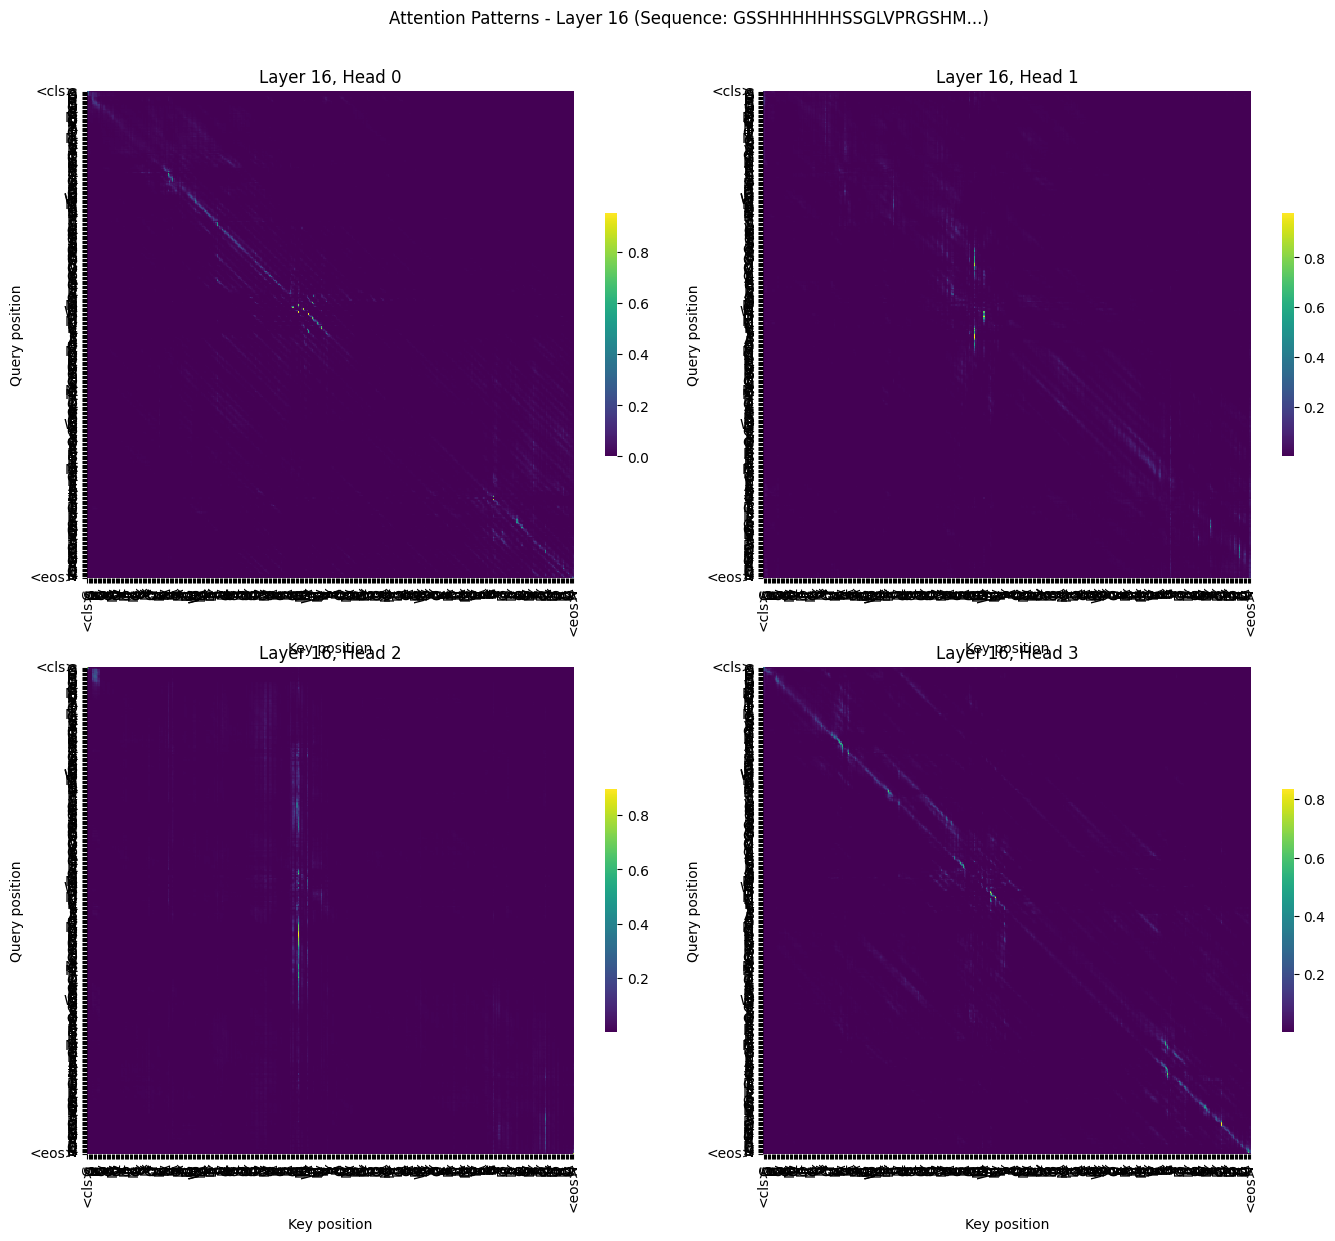

In [12]:
attn_weights_BHLL = attn_out_16_BLD_BHLL[1]  # Shape: (batch, heads, seq, seq)
n_heads = attn_weights_BHLL.shape[1]

# Plot first 4 heads
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for i, ax in enumerate(axes.flat):
    if i < n_heads:
        plot_attention_head(attn_weights_BHLL, layer_idx=16, head_idx=i,
                            tokens_BL=inputs_BL['input_ids'], ax=ax)
plt.suptitle(f'Attention Patterns - Layer 16 (Sequence: {sequence_S[:20]}...)', y=1.02)
plt.tight_layout()
# plt.savefig('attention_layer16.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Saved: attention_layer16.png")

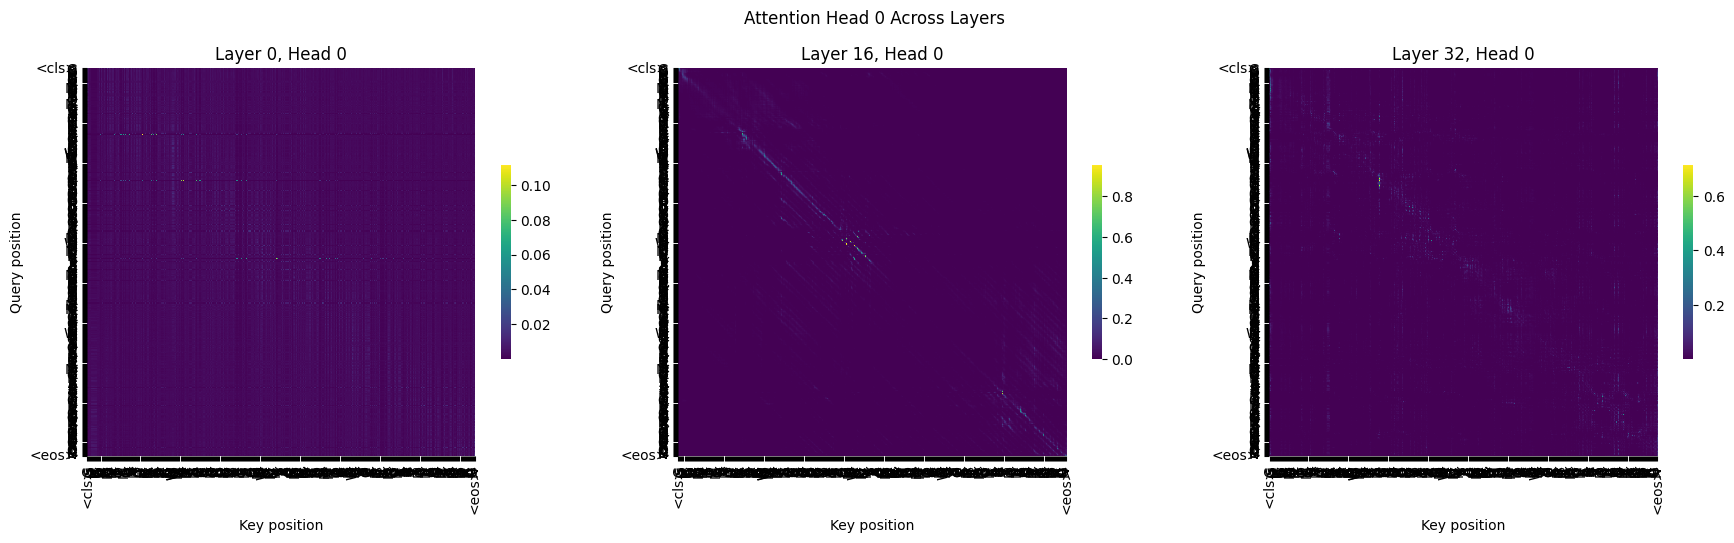

In [13]:
# Compare attention across layers (head 0)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (layer_idx, attn_out) in zip(axes, [
    (0, attn_out_0_BLD_BHLL), (16, attn_out_16_BLD_BHLL), (32, attn_out_32_BLD_BHLL)
]):
    if isinstance(attn_out, tuple) and len(attn_out) > 1:
        plot_attention_head(attn_out[1], layer_idx=layer_idx, head_idx=0,
                          tokens_BL=inputs_BL['input_ids'], ax=ax)

plt.suptitle('Attention Head 0 Across Layers', y=1.02)
plt.tight_layout()
# plt.savefig('attention_across_layers.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Saved: attention_across_layers.png")

### 3.2 Batch Caching with tracer.cache()
For larger analyses, you can cache all layer outputs at once using `tracer.cache()`. This is more efficient than saving outputs one by one.

In [14]:
# Cache all layer outputs in one pass
with model.trace() as tracer:
    with tracer.invoke(**inputs_with_attn_BL):
        cache = tracer.cache(
            modules=[model.esm.encoder.layer[i].attention.self for i in range(33)]
        )

print(f"Cached {len(cache)} modules")
print(f"Keys: {list(cache.keys())[:3]}...")

# Extract all attention weights
all_attention_BHLL = []
for i in range(33):
    key = f"model.esm.encoder.layer.{i}.attention.self"
    if key in cache:
        out_BLD_BHLL = cache[key].output
        if isinstance(out_BLD_BHLL, tuple) and len(out_BLD_BHLL) > 1:
            all_attention_BHLL.append(out_BLD_BHLL[1])  # attention weights

print(f"Collected attention from {len(all_attention_BHLL)} layers")
if all_attention_BHLL:
    print(f"Shape per layer: {all_attention_BHLL[0].shape}")

Cached 33 modules
Keys: ['model.esm.encoder.layer.0.attention.self', 'model.esm.encoder.layer.1.attention.self', 'model.esm.encoder.layer.2.attention.self']...
Collected attention from 33 layers
Shape per layer: torch.Size([1, 20, 379, 379])


## 4 Sparse Autoencoders 

Sparse Autoencoders (SAEs) learn to decompose neural network activations into
sparse, interpretable features. The InterProt project trained SAEs on ESM2 layers.

SAE architecture:
- **Encoder**: hidden → sparse latent (with top-k sparsity)
- **Decoder**: sparse latent → reconstructed hidden

Key methods in `SparseAutoencoder`:
- `encode(x)` → (pre_acts, mu, std) - get pre-activation latents
- `decode(acts, mu, std)` → reconstructed hidden states
- `get_acts(x)` → sparse top-k latent activations
- `forward_val(x)` → full encode/decode pass (inference mode)

In [15]:
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file
from helpers.sae_model_interprot import SparseAutoencoder

def load_sae_prot(esm_dim=1280, sae_dim=4096, layer=24, device="cuda"):
    """Load a Sparse Autoencoder trained for a specific ESM layer.

    Available layers: 6, 12, 18, 24, 30 (for ESM2-650M)
    Available SAE dims: 4096, 8192, 16384
    """
    checkpoint_path = hf_hub_download(
        repo_id="liambai/InterProt-ESM2-SAEs",
        filename=f"esm2_plm{esm_dim}_l{layer}_sae{sae_dim}.safetensors"
    )
    sae = SparseAutoencoder(esm_dim, sae_dim)
    sae.load_state_dict(load_file(checkpoint_path))
    sae.to(device).eval()
    return sae

In [16]:
# Load SAE for layer 24 (a commonly analyzed layer)
LAYER_IDX = 24
sae = load_sae_prot(esm_dim=1280, sae_dim=4096, layer=LAYER_IDX, device=device)

print(f"Loaded SAE for layer {LAYER_IDX}")
print(f"  Input dim (d_model): {sae.d_model}")
print(f"  Hidden dim (d_hidden): {sae.d_hidden}")
print(f"  Top-k sparsity: {sae.k}")

Loaded SAE for layer 24
  Input dim (d_model): 1280
  Hidden dim (d_hidden): 4096
  Top-k sparsity: 128


In [18]:
# Get layer activations using NNsight trace
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Get the hidden states from layer 24
        # ESM layers return (hidden_states, attention_weights) tuple
        layer_hidden_BLD = model.esm.encoder.layer[LAYER_IDX].nns_output.save()

print(f"Layer {LAYER_IDX} hidden states shape: {layer_hidden_BLD.shape}")

Layer 24 hidden states shape: torch.Size([1, 379, 1280])


In [21]:
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Get layer hidden states
        hidden_BLD = model.esm.encoder.layer[LAYER_IDX-1].nns_output

        # Extract AA tokens only (exclude special tokens)
        aa_hidden_BAD = hidden_BLD[:, 1:-1, :]

        # Call SAE inside the trace (ad-hoc module call)
        # This runs the SAE on the live tensor during inference
        sae_output_BAD = sae.forward_val(aa_hidden_BAD).save()

        # Also save original AA hidden for comparison
        original_aa_hidden_BAD = aa_hidden_BAD.save()

print(f"Original AA hidden shape: {original_aa_hidden_BAD.shape}")
print(f"SAE output shape: {sae_output_BAD.shape}")

Original AA hidden shape: torch.Size([1, 377, 1280])
SAE output shape: torch.Size([1, 377, 1280])


In [22]:
# First, get baseline logits (no intervention)
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        baseline_logits_BLV = model.lm_head.output.save()

print(f"Baseline logits shape: {baseline_logits_BLV.shape}")

Baseline logits shape: torch.Size([1, 379, 33])


In [23]:
# Now, intervene: replace layer output with SAE reconstruction
# IMPORTANT: Only modify AA positions, keep special tokens unchanged!
with model.trace() as tracer:
    with tracer.invoke(**inputs_BL):
        # Get the layer's hidden states
        hidden_BLD = model.esm.encoder.layer[LAYER_IDX-1].nns_output

        # Extract AA tokens only (exclude <cls> at 0 and <eos> at -1)
        aa_hidden_BAD = hidden_BLD[:, 1:-1, :]

        # Compute SAE reconstruction on AA tokens only
        sae_recon_aa_BAD = sae.forward_val(aa_hidden_BAD)

        # INTERVENTION: Replace only the AA positions with SAE reconstruction
        # Keep <cls> and <eos> unchanged
        model.esm.encoder.layer[LAYER_IDX-1].nns_output[:, 1:-1, :] = sae_recon_aa_BAD

        # Get logits after intervention
        intervened_logits_BLV = model.lm_head.output.save()

print(f"Intervened logits shape: {intervened_logits_BLV.shape}")

Intervened logits shape: torch.Size([1, 379, 33])


In [24]:
# Compare baseline vs intervened predictions
def top_k_tokens(logits_BLV, tokenizer, k=5):
    """Get top-k predicted tokens for each position."""
    probs_BLV = torch.softmax(logits_BLV, dim=-1)
    top_probs_BLK, top_ids_BLK = probs_BLV.topk(k, dim=-1)
    return top_ids_BLK, top_probs_BLK

baseline_top_BLK, baseline_probs_BLK = top_k_tokens(baseline_logits_BLV[0], tokenizer)
interv_top_BLK, interv_probs_BLK = top_k_tokens(intervened_logits_BLV[0], tokenizer)

# Check if top predictions match
top1_match = (baseline_top_BLK[:, 0] == interv_top_BLK[:, 0]).float().mean().item()
print(f"Top-1 prediction match rate: {top1_match:.1%}")

# Logit difference
logit_diff = (baseline_logits_BLV - intervened_logits_BLV).abs().mean().item()
print(f"Mean absolute logit difference: {logit_diff:.4f}")

# KL divergence between distributions
baseline_log_probs_BLV = torch.log_softmax(baseline_logits_BLV, dim=-1)
interv_probs_full_BLV = torch.softmax(intervened_logits_BLV, dim=-1)
kl_div = (interv_probs_full_BLV * (torch.log_softmax(intervened_logits_BLV, dim=-1) - baseline_log_probs_BLV)).sum(dim=-1).mean().item()
print(f"KL divergence (intervened || baseline): {kl_div:.4f}")


Top-1 prediction match rate: 95.0%
Mean absolute logit difference: 1.0963
KL divergence (intervened || baseline): 0.5577


## 5 Replicating pLM circuits paper in nnsight 